<a href="https://colab.research.google.com/github/deniaulainfead23/bioinformatica/blob/main/aula04/Pratica_de_aula04_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 04 - Introdução à Bioinformática

Nesta prática vamos tratar sequências de DNA como dados computacionais. As sequências são **sintéticas e didáticas**.

> **Você não precisa saber Python.** Leia os comentários iniciados por `#`: eles explicam cada comando.

## 1. Guardando uma sequência em uma variável

Em Python, um texto é uma **string**. O sinal `=` guarda um valor em uma variável, `print()` mostra algo na tela e `len()` conta caracteres.

In [ ]:
# Criamos uma variável chamada sequencia.
# Tudo que está entre aspas é tratado como texto pelo Python.
sequencia = 'ATGCGTACGTTAGCGGCTAA'

# print() mostra um conteúdo na tela.
print('Sequência:', sequencia)

# len() conta quantos caracteres existem na sequência.
print('Tamanho:', len(sequencia))

Sequência: ATGCGTACGTTAGCGGCTAA
Tamanho: 20


## 2. Contando A, T, C e G

O método `.count()` conta quantas vezes um caractere aparece em uma string.

In [ ]:
# Conta cada uma das quatro letras da sequência.
print('Quantidade de A:', sequencia.count('A'))
print('Quantidade de T:', sequencia.count('T'))
print('Quantidade de C:', sequencia.count('C'))
print('Quantidade de G:', sequencia.count('G'))

Quantidade de A: 5
Quantidade de T: 5
Quantidade de C: 4
Quantidade de G: 6


## 3. Conteúdo GC

Vamos transformar letras em uma medida numérica: a porcentagem de G + C. Nesta aula, o objetivo é compreender o processamento, não fazer uma interpretação biológica profunda.

In [ ]:
# Conta quantos G existem.
quantidade_g = sequencia.count('G')

# Conta quantos C existem.
quantidade_c = sequencia.count('C')

# Soma G + C.
total_gc = quantidade_g + quantidade_c

# Divide G+C pelo tamanho total e multiplica por 100.
gc_percentual = 100 * total_gc / len(sequencia)

# :.2f mostra o número com duas casas decimais.
print(f'Conteúdo GC: {gc_percentual:.2f}%')

Conteúdo GC: 50.00%


## 4. Trabalhando com uma pequena base de dados

Vamos usar **pandas**, uma biblioteca para trabalhar com tabelas. `import` traz a biblioteca para o programa.

In [ ]:
# Importa pandas e usa o apelido pd.
import pandas as pd

# Importa a biblioteca de gráficos.
import matplotlib.pyplot as plt

In [ ]:
# Criamos os dados dentro do próprio notebook para facilitar a primeira execução.
dados = {
    'amostra': ['Amostra_A','Amostra_B','Amostra_C','Amostra_D','Amostra_E','Amostra_F'],
    'sequencia': [
        'ATGCGTACGTTAGCGGCTAA',
        'ATATATGCGTATATGCAAAT',
        'GCGCGCGTACGCGGCCGTAA',
        'ATGCCCTTAGGCTAACCGTA',
        'TTATTAACGATATTAACGTA',
        'CCGGCGGCCGATCGGCGCTA'
    ]
}

# DataFrame transforma os dados em uma tabela.
df = pd.DataFrame(dados)

# Exibe a tabela.
df

,amostra,sequencia
0,Amostra_A,ATGCGTACGTTAGCGGCTAA
1,Amostra_B,ATATATGCGTATATGCAAAT
2,Amostra_C,GCGCGCGTACGCGGCCGTAA
3,Amostra_D,ATGCCCTTAGGCTAACCGTA
4,Amostra_E,TTATTAACGATATTAACGTA
5,Amostra_F,CCGGCGGCCGATCGGCGCTA


## 5. Criando novas colunas

Agora calcularemos o tamanho e o conteúdo GC para todas as linhas.

In [ ]:
# .str.len() calcula o tamanho de cada texto da coluna sequencia.
df['tamanho'] = df['sequencia'].str.len()

# Criamos uma função. Ela recebe uma sequência e devolve o percentual GC.
def calcular_gc(s):
    return 100 * (s.count('G') + s.count('C')) / len(s)

# .apply() executa calcular_gc em cada linha da coluna sequencia.
df['gc_percentual'] = df['sequencia'].apply(calcular_gc)

# Mostra a tabela atualizada.
df

,amostra,sequencia,tamanho,gc_percentual
0,Amostra_A,ATGCGTACGTTAGCGGCTAA,20,50.0
1,Amostra_B,ATATATGCGTATATGCAAAT,20,25.0
2,Amostra_C,GCGCGCGTACGCGGCCGTAA,20,75.0
3,Amostra_D,ATGCCCTTAGGCTAACCGTA,20,50.0
4,Amostra_E,TTATTAACGATATTAACGTA,20,20.0
5,Amostra_F,CCGGCGGCCGATCGGCGCTA,20,80.0


## 6. Criando um gráfico

A visualização ajuda a comparar as amostras.

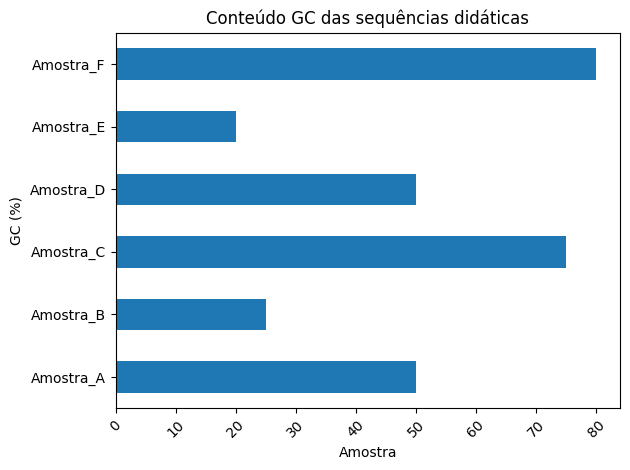

In [ ]:
# Cria um gráfico de barras.
df.plot(x='amostra', y='gc_percentual', kind='barh', legend=False)

# Adiciona título e nomes dos eixos.
plt.title('Conteúdo GC das sequências didáticas')
plt.xlabel('Amostra')
plt.ylabel('GC (%)')


# Gira os nomes das amostras.
plt.xticks(rotation=45)

# Ajusta e mostra o gráfico.
plt.tight_layout()
plt.show()

#tipos de gráficos que trabalham com x e y de dados
#kind='line'  kind='bar'  kind='barh' kind='area'

## 7. Desafio

Crie uma coluna `at_percentual` com a proporção de A + T. Antes do código, escreva o algoritmo em português.

**Ideia principal:** dado biológico → representação computacional → processamento → medida → interpretação.

### Algoritmo para calcular a porcentagem de A + T:

1.  **Definir uma função `calcular_at` que recebe uma sequência de DNA (string) como entrada.**
2.  Dentro da função:
    a.  Contar o número de ocorrências da base 'A' na sequência.
    b.  Contar o número de ocorrências da base 'T' na sequência.
    c.  Somar as contagens de 'A' e 'T' para obter o total de bases A+T.
    d.  Obter o comprimento total da sequência.
    e.  Calcular a porcentagem de A+T dividindo o total de bases A+T pelo comprimento total da sequência e multiplicando por 100.
    f.  Retornar o valor percentual.
3.  **Aplicar esta função à coluna `sequencia` do DataFrame `df`.**
4.  **Armazenar o resultado em uma nova coluna chamada `at_percentual` no DataFrame `df`.**
5.  **Exibir o DataFrame atualizado.**

In [ ]:
# Criamos uma função para calcular o percentual de A + T.
def calcular_at(v):
    return 100 * (v.count('A') + v.count('T')) / len(v) #cálculo da porcentagem

# .apply() executa calcular_at em cada linha da coluna 'sequencia'.
df['at_percentual'] = df['sequencia'].apply(calcular_at)

# Mostra a tabela atualizada com a nova coluna.
display(df)

#lembra que o df foi criado no Passo 4
# PASSO 4 -
# DataFrame transforma os dados em uma tabela.
# df = pd.DataFrame(dados)

,amostra,sequencia,tamanho,gc_percentual,at_percentual
0,Amostra_A,ATGCGTACGTTAGCGGCTAA,20,50.0,50.0
1,Amostra_B,ATATATGCGTATATGCAAAT,20,25.0,75.0
2,Amostra_C,GCGCGCGTACGCGGCCGTAA,20,75.0,25.0
3,Amostra_D,ATGCCCTTAGGCTAACCGTA,20,50.0,50.0
4,Amostra_E,TTATTAACGATATTAACGTA,20,20.0,80.0
5,Amostra_F,CCGGCGGCCGATCGGCGCTA,20,80.0,20.0
